# 0. Kaggleからデータのダウンロード・解凍

In [ ]:
!pip install kaggle 

In [ ]:
import os
import json

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# f = open('/content/drive/MyDrive/kaggle/kaggle.json', 'r')
# json_date = json.load(f)
# os.environ['KAGGLE_USERNAME'] = json_date['username']
# os.environ['KAGGLE_KEY'] = json_date['key']

In [ ]:
# データのダウンロードと解凍
# !kaggle competitions download -c ambl-california-housing -p /content/drive/MyDrive/kaggle/data
# !unzip /content/drive/MyDrive/kaggle/ambl-california-housing.zip -d /content/drive/MyDrive/kaggle/data

ambl-california-housing.zip: Skipping, found more recently modified local copy (use --force to force download)
unzip:  cannot find or open /content/drive/MyDrive/kaggle/ambl-california-housing.zip, /content/drive/MyDrive/kaggle/ambl-california-housing.zip.zip or /content/drive/MyDrive/kaggle/ambl-california-housing.zip.ZIP.


# 1. 前処理

## モジュールインポート

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# 前処理(正規化・標準化)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# データ分割
from sklearn.model_selection import train_test_split

# 線形モデル
from sklearn.linear_model import LinearRegression

# 精度評価
from sklearn.metrics import mean_squared_error

# グラフをアウトプット行に出力するためのマジックコマンド
%matplotlib inline

## データセットの読み込み

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/kaggle/data/train.csv')
test = pd.read_csv('/content/drive/MyDrive/kaggle/data/test.csv')
sample = pd.read_csv('/content/drive/MyDrive/kaggle/data/sample.csv')

In [ ]:
train.head(5)

,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Household,AllRooms,AllBedrms,Price
0,0,1.4817,6.0,4.443645,1.134293,1397.0,3.350120,36.77,-119.84,417.0,1853.0,473.0,0.720
1,1,6.9133,8.0,5.976471,1.026471,862.0,2.535294,33.68,-117.80,340.0,2032.0,349.0,2.741
2,2,1.5536,25.0,4.088785,1.000000,931.0,4.350467,36.60,-120.19,214.0,875.0,214.0,0.583
3,3,1.5284,31.0,2.740088,1.008811,597.0,2.629956,34.10,-118.32,227.0,622.0,229.0,2.000
4,4,4.0815,21.0,5.166667,1.002688,1130.0,3.037634,37.79,-121.23,372.0,1922.0,373.0,1.179


## 可視化

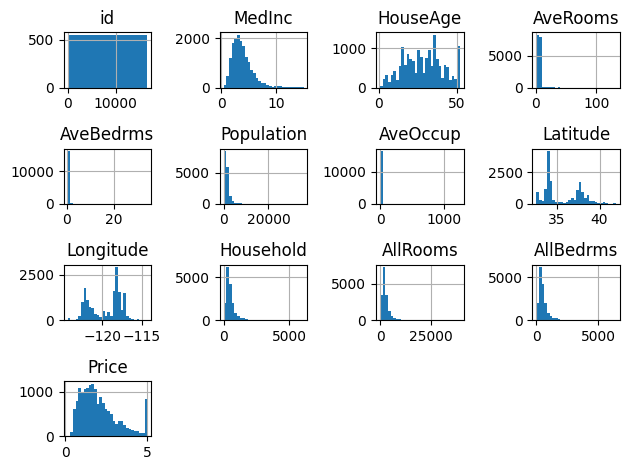

In [ ]:
# 分布状況の可視化
train.hist(bins=30)
plt.tight_layout()

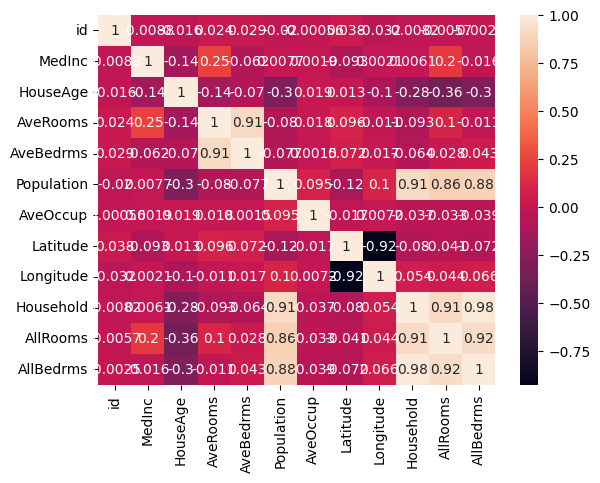

In [ ]:
# 相関係数
cor = test.corr()

# ヒートマップ
sns.heatmap(cor, annot=True)
plt.show()

## 特徴量作成

In [ ]:
# 世帯数(Household)を求める
train['Household'] = train['Population'] / train['AveOccup']
test['Household'] = test['Population'] / test['AveOccup']

# 合計居室数(AllRooms)と合計寝室数(AllBedrms)を求める
train["AllRooms"] = train["Household"] * train["AveRooms"]
train["AllBedrms"] = train["Household"] * train["AveBedrms"]
test["AllRooms"] = test["Household"] * test["AveRooms"]
test["AllBedrms"] = test["Household"] * test["AveBedrms"]

データ分割

In [ ]:
# データを説明変数と目的変数に分ける
train_X = train.drop(['Price', 'id'], axis=1)
target = train['Price']

print('データ分割前の行数' ,len(train_X))

データ分割前の行数 16512


In [ ]:
# データの分割(学習用データ80% 検証用データ 20%)
# test_sizeで検証用データの割合を設定することができる

X_train, X_test, y_train, y_test = train_test_split(train_X, target, test_size=0.2, random_state=2)

# 分割後のデータ数を確認
print('学習用データの行数' ,len(X_train))
print('検証用用データの行数' ,len(X_test))

学習用データの行数 13209
検証用用データの行数 3303


特徴量選択

In [ ]:
# RFE法を利用した特徴量選択（変数選択）
from sklearn.feature_selection import RFE

# インスタンス
rfe = RFE(LinearRegression())

# 特徴量選定（変数選択）の実施
X_rfe = rfe.fit(X_train,y_train)
X_selected = X_train.columns[X_rfe.support_]

# 選択した特徴量
print(X_selected)

Index(['MedInc', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude'], dtype='object')


# 2. モデルの学習

In [ ]:
# xgboostのimport
from xgboost import XGBRFRegressor

# xgboostのインスタンス化
XGBoost = XGBRFRegressor()

# 学習の実行
model = XGBoost.fit(X_train[X_selected], y_train)

# モデルの予測 学習済みモデルを使用して、新しいデータに対して予測を行うために、predict関数を利用できます。
pred_xg_train = model.predict(X_train[X_selected])
pred_xg_test = model.predict(X_test[X_selected])

# 数値の丸め込み処理 0以下を0に5.00001以上を5.00001に変換する
pred_xg_train_rounding = np.where(pred_xg_train <= 0, 0, pred_xg_train)
pred_xg_train_rounding = np.where(pred_xg_train_rounding >= 5.00001, 5.00001, pred_xg_train_rounding)

pred_xg_test_rounding = np.where(pred_xg_test <= 0, 0, pred_xg_test)
pred_xg_test_rounding = np.where(pred_xg_test_rounding >= 5.00001, 5.00001, pred_xg_test_rounding)

# 3. 精度評価

In [ ]:
# RMSE RMSEはMSEに√を付けたものになるのでnp.sqrt()でMSEを囲んで算出する
print('RMSE_train',np.sqrt(mean_squared_error(y_train, pred_xg_train_rounding)))
print('RMSE_test',np.sqrt(mean_squared_error(y_test, pred_xg_test_rounding)))

RMSE_train 0.6594998267027213
RMSE_test 0.6695383803173565


提出用ファイル

In [ ]:
# 学習データ全てを使って学習します
model = XGBoost.fit(train_X[X_selected], target)

# モデルの予測 学習済みモデルを使用して、新しいデータに対して予測を行うために、predict関数を利用できます。
pred_xg = model.predict(test[X_selected])

# 数値の丸め込み処理 0以下を0に5.00001以上を5.00001に変換する
pred_xg_rounding = np.where(pred_xg <= 0, 0, pred_xg)
pred_xg_rounding = np.where(pred_xg_rounding >= 5.00001, 5.00001, pred_xg_rounding)

In [ ]:
# sampleに予測値の代入と提出ファイルの作成
sample['Price'] = pred_xg_rounding
sample

,id,Price
0,0,3.021581
1,1,1.598195
2,2,1.228339
3,3,2.934713
4,4,3.896111
...,...,...
4123,4123,1.768874
4124,4124,0.961463
4125,4125,1.428346
4126,4126,1.234307


In [ ]:
submit_file = 'tutorial_submit.csv'

In [ ]:
# csvファイルの作成
os.makedirs('/content/drive/MyDrive/kaggle/submit', exist_ok=True)
sample.to_csv(f'/content/drive/MyDrive/kaggle/submit/{submit_file}',index=None)

In [ ]:
# 作成したファイルをKaggleに直接投稿
# -c:提出コンペ名
# -f：ファイル名
# -m：投稿コメント

!kaggle competitions submit -c ambl-california-housing -f /content/drive/MyDrive/kaggle/submit/$submit_file -m "Yeah! I submit my file through the Google Colab!"

100% 58.7k/58.7k [00:00<00:00, 207kB/s]
Successfully submitted to AMBL初心者向けコンペティション_California Housing